In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/cclass.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/unclean cclass.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/focus.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/audi.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/toyota.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/skoda.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/ford.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/vauxhall.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/bmw.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/vw.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/hyundi.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/unclean focus.csv


# 1. Preparation

## 1.1. Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1.2. Data Acquisition

In [3]:
df = pd.read_csv("/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/toyota.csv")

# 2. Exploratory Data Analysis (EDA)

## 2.1. Dataset Overview
### Data Shape & Columns

In [4]:
df.shape

(6738, 9)

### Data sample

In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


### Dataset Summary

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


No missing value.

### Descriptive Statistics

In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000
mean,2016.748145,12522.391066,22857.413921,94.697240,63.042223,1.471297
std,2.204062,6345.017587,19125.464147,73.880776,15.836710,0.436159
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8290.000000,9446.000000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18513.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31063.750000,145.000000,69.000000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


In [8]:
df.describe(include='object') 

,model,transmission,fuelType
count,6738,6738,6738
unique,18,4,4
top,Yaris,Manual,Petrol
freq,2122,3826,4087


## 2.2. Target Distribution

<Axes: xlabel='price', ylabel='Count'>

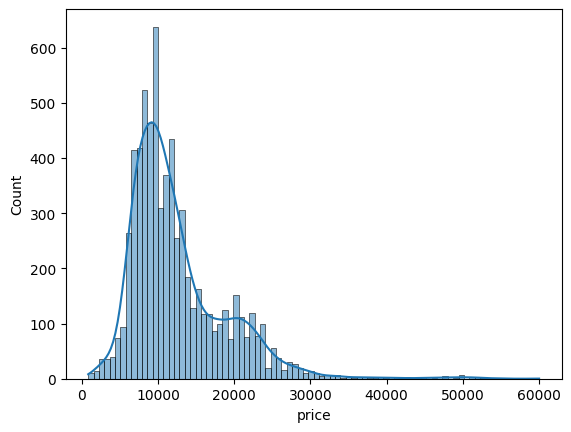

In [9]:
sns.histplot(df['price'], kde=True)

In [10]:
# Skewness & Kurtosis
print("Skewness: %f" % df['price'].skew())
print("Kurtosis: %f" % df['price'].kurt())

Skewness: 1.816743
Kurtosis: 5.810489


## 2.3. Correlation Matrix

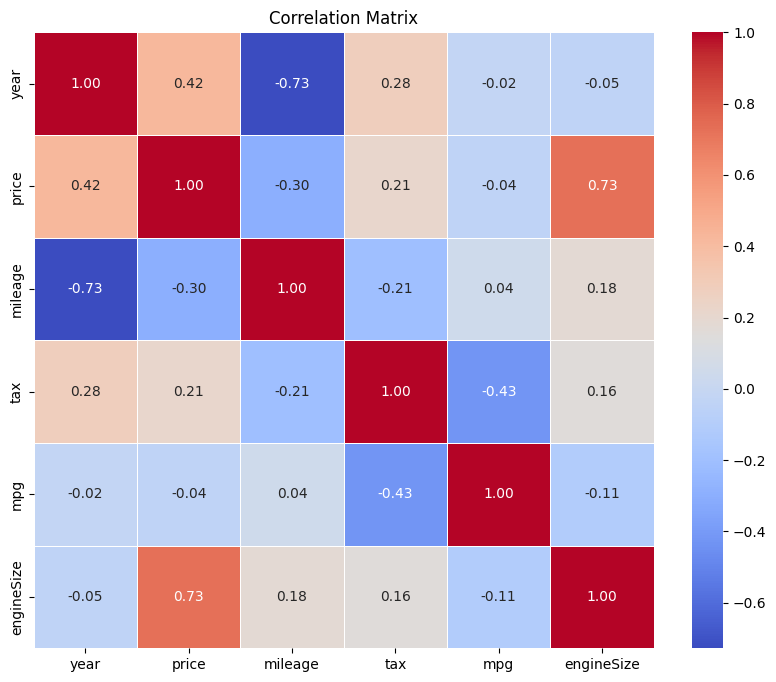

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## 2.4. Numerical feature distribution
### `year` feature distribution

Skewness: -2.209687
Kurtosis: 9.218032


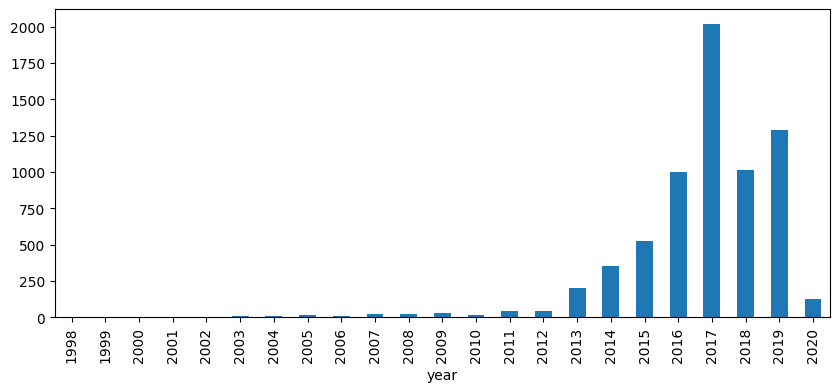

In [12]:
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))

# Skewness & Kurtosis
print("Skewness: %f" % df['year'].skew())
print("Kurtosis: %f" % df['year'].kurt())

### `mileage` feature distribution

Skewness: 1.900918
Kurtosis: 6.066796


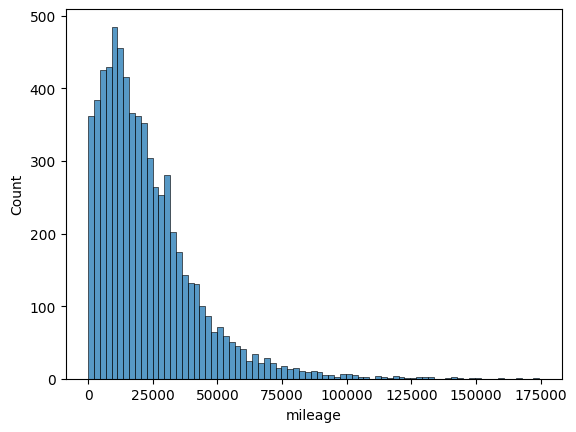

In [13]:
sns.histplot(df['mileage'])

# Skewness & Kurtosis
print("Skewness: %f" % df['mileage'].skew())
print("Kurtosis: %f" % df['mileage'].kurt())

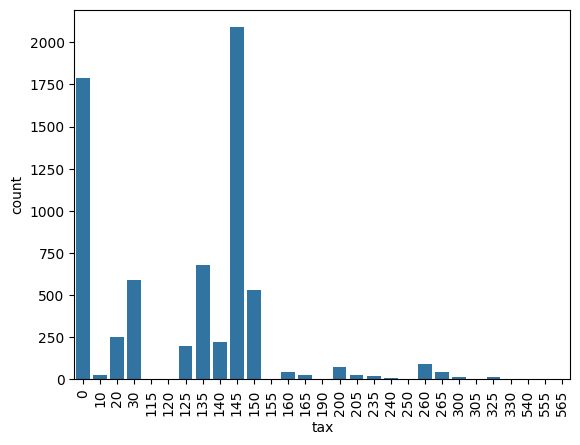

In [14]:
sns.countplot(x='tax', data=df)
plt.xticks(rotation=90);

Mutli modal distribution.

Skewness: 3.481777
Kurtosis: 36.460424


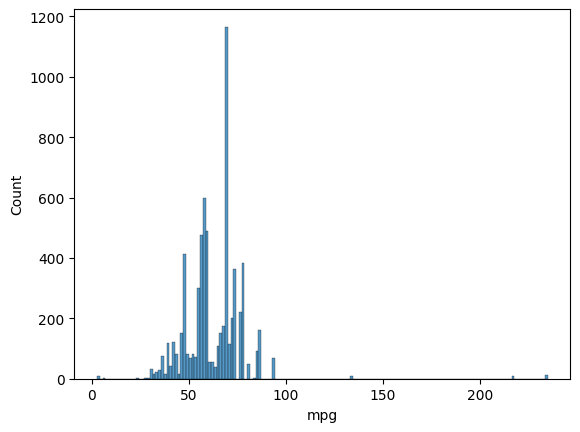

In [15]:
sns.histplot(df['mpg'])

# Skewness & Kurtosis
print("Skewness: %f" % df['mpg'].skew())
print("Kurtosis: %f" % df['mpg'].kurt())

Skewness: 0.838212
Kurtosis: 0.973630


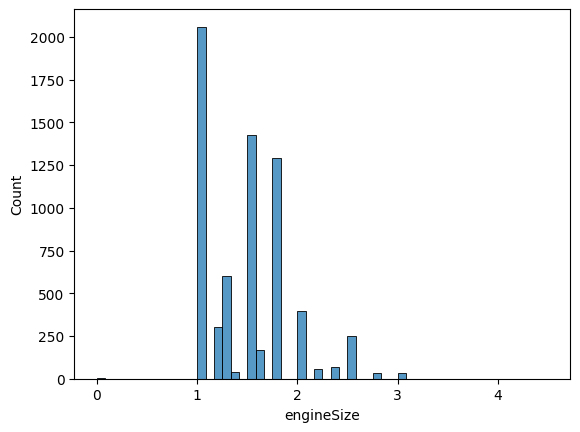

In [16]:
sns.histplot(df['engineSize'])

# Skewness & Kurtosis
print("Skewness: %f" % df['engineSize'].skew())
print("Kurtosis: %f" % df['engineSize'].kurt())